In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Twitter_Data.csv")

In [3]:
#display first 5rows
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [4]:
# Column names
print("\nColumns:")
print(df.columns)


Columns:
Index(['clean_text', 'category'], dtype='object')


In [5]:
# Dataset information
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139423 entries, 0 to 139422
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  139422 non-null  object 
 1   category    139421 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.1+ MB


In [7]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
clean_text    1
category      2
dtype: int64


In [8]:
# Check sentiment distribution
print("\nSentiment Distribution:")
print(df["category"].value_counts(dropna=False))



Sentiment Distribution:
category
 1.0    61754
 0.0    47204
-1.0    30463
 NaN        2
Name: count, dtype: int64


In [9]:
# Remove rows with missing text or sentiment
df = df.dropna(subset=["clean_text", "category"])

In [11]:
# Convert category to integer
df["category"] = df["category"].astype(int)
print("Dataset after cleaning:")
print(df.shape)

print("\nSentiment Distribution:")
print(df["category"].value_counts())

Dataset after cleaning:
(139420, 2)

Sentiment Distribution:
category
 1    61754
 0    47203
-1    30463
Name: count, dtype: int64


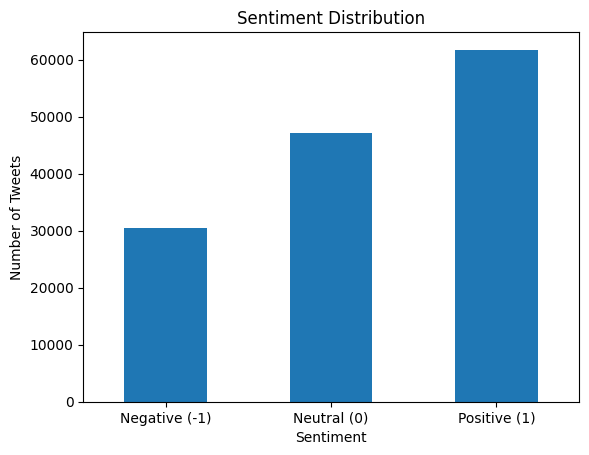

In [12]:
import matplotlib.pyplot as plt

df["category"].value_counts().sort_index().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(
    ticks=[0, 1, 2],
    labels=["Negative (-1)", "Neutral (0)", "Positive (1)"],
    rotation=0
)

plt.show()

In [13]:
import re

def clean_text(text):
    text = str(text).lower()

In [17]:
import re

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Keep only letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["processed_text"] = df["clean_text"].apply(clean_text)

# Check results
display(df[["clean_text", "processed_text"]].head())

,clean_text,processed_text
0,when modi promised “minimum government maximum...,when modi promised minimum government maximum ...
1,talk all the nonsense and continue all the dra...,talk all the nonsense and continue all the dra...
2,what did just say vote for modi welcome bjp t...,what did just say vote for modi welcome bjp to...
3,asking his supporters prefix chowkidar their n...,asking his supporters prefix chowkidar their n...
4,answer who among these the most powerful world...,answer who among these the most powerful world...


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

# Convert text into numerical features
X = vectorizer.fit_transform(df["processed_text"])

# Target variable
y = df["category"]

print("TF-IDF shape:", X.shape)

TF-IDF shape: (139420, 5000)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 111536
Testing samples: 27884


In [20]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(
    max_iter=1000
)

# Train model
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [21]:
# Predict test data
y_pred = model.predict(X_test)

# Show some predictions
print("Actual:", y_test.values[:10])
print("Predicted:", y_pred[:10])

Actual: [ 0 -1  1  1  0 -1  1  0  0  1]
Predicted: [ 0 -1  1  1  0 -1  1  0  0  1]


In [22]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_test, y_pred)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy:", accuracy)
print("F1 Score:", f1)

Accuracy: 0.8562616554296371
F1 Score: 0.8550437209677562


In [23]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Neutral", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.86      0.74      0.80      6093
     Neutral       0.80      0.96      0.87      9440
    Positive       0.91      0.84      0.87     12351

    accuracy                           0.86     27884
   macro avg       0.86      0.84      0.85     27884
weighted avg       0.86      0.86      0.86     27884



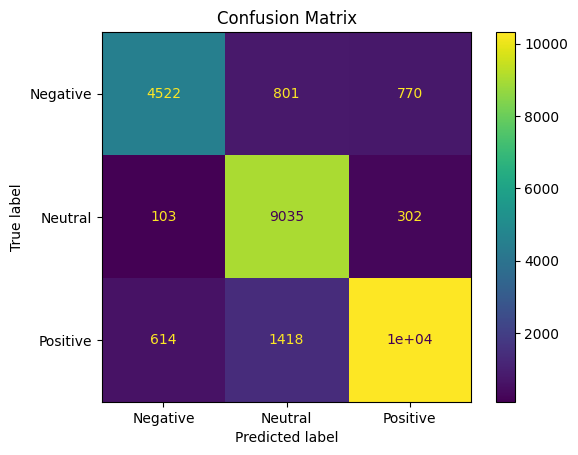

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [25]:
# Your own sentences
custom_sentences = [
    "This is the best experience I have ever had",
    "I completely hate this product",
    "The service was okay and nothing special"
]

# Clean the sentences
cleaned_sentences = [
    clean_text(sentence)
    for sentence in custom_sentences
]

# Convert using the SAME TF-IDF vectorizer
custom_vectors = vectorizer.transform(cleaned_sentences)

# Predict sentiment
custom_predictions = model.predict(custom_vectors)

# Convert labels to names
sentiment_names = {
    -1: "Negative",
     0: "Neutral",
     1: "Positive"
}

# Display predictions
for sentence, prediction in zip(
    custom_sentences,
    custom_predictions
):
    print("Sentence:", sentence)
    print("Predicted Sentiment:", sentiment_names[prediction])
    print()

Sentence: This is the best experience I have ever had
Predicted Sentiment: Positive

Sentence: I completely hate this product
Predicted Sentiment: Negative

Sentence: The service was okay and nothing special
Predicted Sentiment: Positive



In [26]:
custom_probabilities = model.predict_proba(custom_vectors)

for sentence, prediction, probability in zip(
    custom_sentences,
    custom_predictions,
    custom_probabilities
):
    print("Sentence:", sentence)
    print("Prediction:", sentiment_names[prediction])
    print("Confidence:", round(max(probability) * 100, 2), "%")
    print("-" * 50)

Sentence: This is the best experience I have ever had
Prediction: Positive
Confidence: 99.86 %
--------------------------------------------------
Sentence: I completely hate this product
Prediction: Negative
Confidence: 98.4 %
--------------------------------------------------
Sentence: The service was okay and nothing special
Prediction: Positive
Confidence: 99.84 %
--------------------------------------------------


In [27]:
print("=" * 50)
print("FINAL MODEL RESULTS")
print("=" * 50)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")
print(f"TF-IDF Features: {X.shape[1]}")

FINAL MODEL RESULTS
Accuracy: 0.8563
F1 Score: 0.8550
Training Samples: 111536
Testing Samples: 27884
TF-IDF Features: 5000
